In [200]:
!pip install numpy pandas matplotlib opencv-python scikit-learn tensorflow seaborn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [201]:
import numpy as np
import cv2
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model


In [216]:
data_dir = "COVID-19_Radiography_Dataset"

classes = ["COVID", "Normal", "Viral Pneumonia", "Lung_Opacity"]

IMG_SIZE = 160
LIMIT_PER_CLASS = 800

In [217]:
def load_data():
    images = []
    labels = []
    
    for label, category in enumerate(classes):
        path = os.path.join(data_dir, category, "images")
        count = 0
        
        for img_name in os.listdir(path):
            if count >= LIMIT_PER_CLASS:
                break
            
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)
            
            if img is None:
                continue
            
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = preprocess_input(img)
            
            images.append(img)
            labels.append(label)
            count += 1
    
    return np.array(images), np.array(labels)

In [218]:
X, y = load_data()

# Check balance
for i, cls in enumerate(classes):
    print(cls, sum(y == i))

X, y = shuffle(X, y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

COVID 800
Normal 800
Viral Pneumonia 800
Lung_Opacity 800


In [219]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

In [220]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

feature_model = Model(inputs=base_model.input, outputs=x)

In [247]:
X_train_feat = feature_model.predict(X_train, batch_size=32)
X_test_feat  = feature_model.predict(X_test, batch_size=32)

print(X_train_feat.shape)
print(X_test_feat.shape)

80/80 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step
(2560, 1024)
(640, 1024)


In [248]:
scaler = StandardScaler()

X_train_feat = scaler.fit_transform(X_train_feat)
X_test_feat  = scaler.transform(X_test_feat)

In [249]:
from sklearn.decomposition import PCA


n_features = X_train_feat.shape[1]

pca = PCA(n_components=min(300, n_features))

X_train_feat = pca.fit_transform(X_train_feat)
X_test_feat  = pca.transform(X_test_feat)

In [250]:
print(pca.n_features_in_)
print(X_train_feat.shape)

1024
(2560, 300)


In [251]:
svm_model = SVC(
    kernel='rbf',
    C=30,
    gamma='scale',
    probability=True   # 🔥 IMPORTANT
)

svm_model.fit(X_train_feat, y_train)

,C,30
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [252]:
y_pred = svm_model.predict(X_test_feat)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.91875
              precision    recall  f1-score   support

           0       0.99      0.91      0.94       160
           1       0.86      0.89      0.88       160
           2       0.97      0.97      0.97       160
           3       0.86      0.91      0.88       160

    accuracy                           0.92       640
   macro avg       0.92      0.92      0.92       640
weighted avg       0.92      0.92      0.92       640



In [242]:
unique, counts = np.unique(y_pred, return_counts=True)

for i in range(len(unique)):
    print(classes[unique[i]], counts[i])

COVID 147
Normal 164
Viral Pneumonia 160
Lung_Opacity 169


In [243]:
for i in range(10):
    print("Actual:", classes[y_test[i]], 
          "| Predicted:", classes[y_pred[i]])

Actual: Normal | Predicted: Normal
Actual: Lung_Opacity | Predicted: Lung_Opacity
Actual: Normal | Predicted: Normal
Actual: Normal | Predicted: Normal
Actual: COVID | Predicted: Lung_Opacity
Actual: Lung_Opacity | Predicted: Normal
Actual: Lung_Opacity | Predicted: Lung_Opacity
Actual: Viral Pneumonia | Predicted: Viral Pneumonia
Actual: Lung_Opacity | Predicted: Lung_Opacity
Actual: Viral Pneumonia | Predicted: Viral Pneumonia


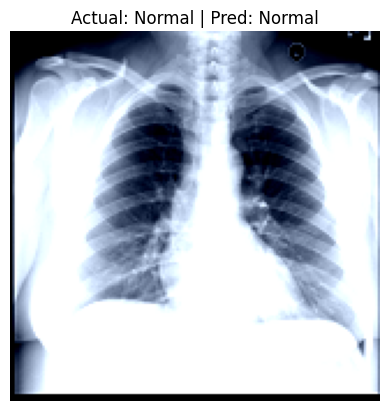

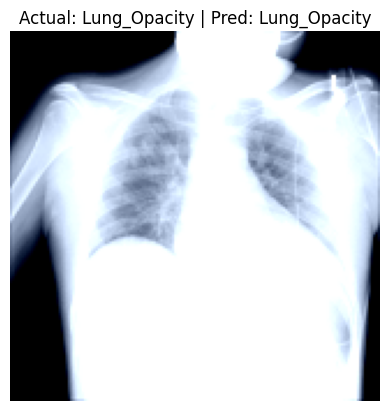

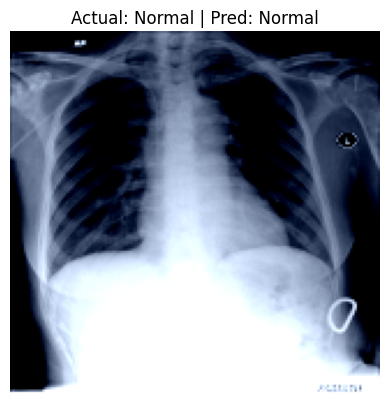

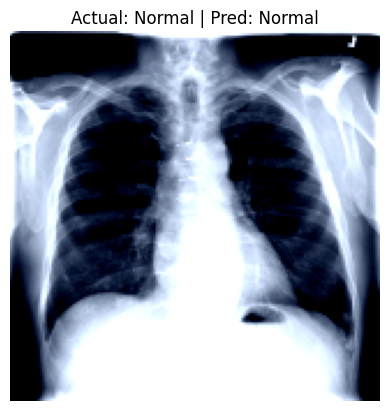

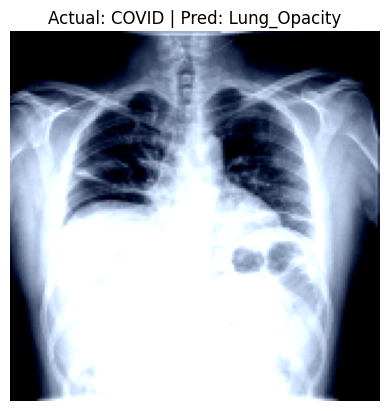

In [244]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow((X_test[i] + 1) / 2)  # fix normalization for display
    plt.title(f"Actual: {classes[y_test[i]]} | Pred: {classes[y_pred[i]]}")
    plt.axis("off")
    plt.show()

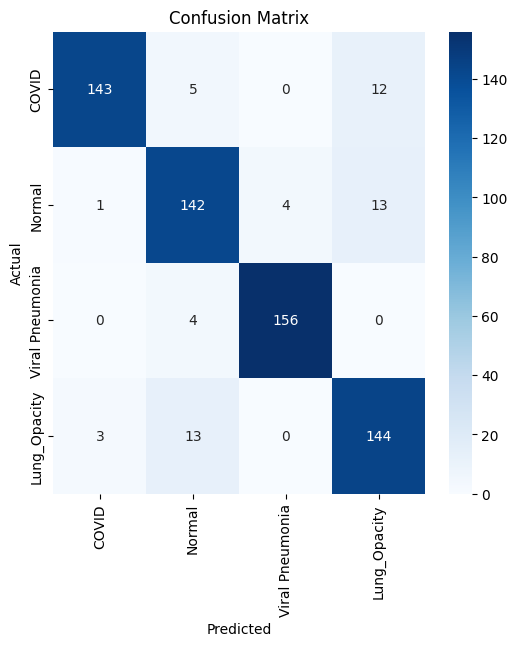

In [245]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [253]:
import joblib

# Save SVM + scaler + PCA
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")

# Save CNN feature extractor
feature_model.save("cnn_feature_extractor.h5")